<a href="https://colab.research.google.com/github/yansiercaro/TelecomX_LATAM/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

### En esta etapa vamos a extraer los datos directamente desde la API y lo convertiremos en una data frame de pandas para su manipulacion.

In [1]:
import pandas as pd
import requests

url_raw = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

try:
    response = requests.get(url_raw)
    response.raise_for_status()

    # Cargar datos y convertirlos en un dataframe
    data = response.json()
    df_clientes_1 = pd.DataFrame(data)

    print("✓ Datos cargados correctamente desde el repositorio.")
    print(f"Dataset: {df_churn.shape[0]} filas y {df_churn.shape[1]} columnas.")

except Exception as e:
    print(f"Error: {e}")

df_clientes_1.head()

✓ Datos cargados correctamente desde el repositorio.
Error: name 'df_churn' is not defined


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [3]:
#Ver la estructura general y tipos de datos
print("--- Estructura General del Dataset ---")
df_clientes_1.info()

print("\n--- Tipos de Datos Detallados ---")
print(df_clientes_1.dtypes)

print("\n--- Conteo de Valores Nulos por Columna ---")
print(df_clientes_1.isnull().sum())

print("\n--- Muestra Aleatoria de 5 registros ---")
display(df_clientes_1.sample(5))

--- Estructura General del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB

--- Tipos de Datos Detallados ---
customerID    object
Churn         object
customer      object
phone         object
internet      object
account       object
dtype: object

--- Conteo de Valores Nulos por Columna ---
customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64

--- Muestra Aleatoria de 5 registros ---


,customerID,Churn,customer,phone,internet,account
704,1010-DIAUQ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3493,4822-YCXMX,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3396,4707-MAXGU,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Two year', 'PaperlessBilling': '..."
6831,9418-RUKPH,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Two year', 'PaperlessBilling': '..."
4845,6629-LADHQ,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [6]:
df_customer = pd.json_normalize(df_clientes_1['customer'])
df_phone = pd.json_normalize(df_clientes_1['phone'])
df_internet = pd.json_normalize(df_clientes_1['internet'])
df_account = pd.json_normalize(df_clientes_1['account'])

# 2. Concatenamos todo en un solo DataFrame limpio
df_final = pd.concat([df_clientes_1[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

# 3. Verificamos el resultado
print("Nuevas columnas generadas:")
print(df_final.columns.tolist())
display(df_final.head())

Nuevas columnas generadas:
['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [7]:
# 1. Renombrar columnas con puntos para evitar errores de sintaxis
df_final.rename(columns={
    'Charges.Monthly': 'MonthlyCharges',
    'Charges.Total': 'TotalCharges'
}, inplace=True)

# 2. Convertir TotalCharges a numérico (Float)
df_final['TotalCharges'] = pd.to_numeric(df_final['TotalCharges'], errors='coerce')

# 3. Eliminar filas donde TotalCharges resultó nulo (clientes con 0 meses de antigüedad)
df_final.dropna(subset=['TotalCharges'], inplace=True)

print(f"✓ Tipos de datos corregidos. Registros finales: {len(df_final)}")

✓ Tipos de datos corregidos. Registros finales: 7256


In [8]:
cols_a_simplificar = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                      'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_a_simplificar:
    df_final[col] = df_final[col].replace('No internet service', 'No')

# Simplificar MultipleLines
df_final['MultipleLines'] = df_final['MultipleLines'].replace('No phone service', 'No')

print("✓ Valores categóricos simplificados para el análisis.")

✓ Valores categóricos simplificados para el análisis.


In [9]:
# Transformar Churn a numérico
df_final['Churn'] = df_final['Churn'].map({'Yes': 1, 'No': 0})

# Mostrar el balance de la variable objetivo
print("\n--- Estado de Evasión (Churn) ---")
print(df_final['Churn'].value_counts(normalize=True) * 100)


--- Estado de Evasión (Churn) ---
Churn
0.0    73.421502
1.0    26.578498
Name: proportion, dtype: float64


In [10]:
# Verificación final de salud del dataframe
display(df_final[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

,tenure,MonthlyCharges,TotalCharges
count,7256.000000,7256.000000,7256.000000
mean,32.395535,64.755423,2280.634213
std,24.558067,30.125739,2268.632997
min,1.000000,18.250000,18.800000
25%,9.000000,35.450000,400.225000
50%,29.000000,70.300000,1391.000000
75%,55.000000,89.900000,3785.300000
max,72.000000,118.750000,8684.800000


In [11]:
# 1. Calcular el cargo diario basado en el cargo mensual
df_final['Cuentas_Diarias'] = (df_final['MonthlyCharges'] / 30).round(2)

# 2. Verificar la creación de la nueva columna y ver los primeros registros
print("✓ Columna 'Cuentas_Diarias' creada exitosamente.")
display(df_final[['customerID', 'MonthlyCharges', 'Cuentas_Diarias']].head())

✓ Columna 'Cuentas_Diarias' creada exitosamente.


,customerID,MonthlyCharges,Cuentas_Diarias
0,0002-ORFBO,65.6,2.19
1,0003-MKNFE,59.9,2.00
2,0004-TLHLJ,73.9,2.46
3,0011-IGKFF,98.0,3.27
4,0013-EXCHZ,83.9,2.80


In [12]:
df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


## Traducción de columnas

In [15]:
# Diccionario de traducción para mayor claridad
traduccion_columnas = {
    'gender': 'Genero',
    'SeniorCitizen': 'Adulto_Mayor',
    'Partner': 'Tiene_Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Meses_Antigüedad',
    'PhoneService': 'Servicio_Telefonico',
    'Contract': 'Tipo_Contrato',
    'MonthlyCharges': 'Cargos_Mensuales',
    'TotalCharges': 'Cargos_Totales',
    'Churn': 'Fuga_Cliente'
}

df_final.rename(columns=traduccion_columnas, inplace=True)
print("✓ Columnas traducidas para mejorar la comunicación con personal.")

✓ Columnas traducidas para mejorar la comunicación con personal.


## Binarización de valores

In [16]:
# Mapeo de valores textuales a binarios
mapa_binario = {'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0}

# Aplicamos a columnas lógicas
cols_binarias = ['Tiene_Pareja', 'Dependientes', 'Servicio_Telefonico', 'PaperlessBilling']

for col in cols_binarias:
    if col in df_final.columns:
        df_final[col] = df_final[col].map(mapa_binario)

print("✓ Transformación binaria completada (1 y 0).")

✓ Transformación binaria completada (1 y 0).


In [17]:
df_final.head()

,customerID,Fuga_Cliente,Genero,Adulto_Mayor,Tiene_Pareja,Dependientes,Meses_Antigüedad,Servicio_Telefonico,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Tipo_Contrato,PaperlessBilling,PaymentMethod,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [18]:
# Lista de todas las columnas de servicios detectadas en tus imágenes
columnas_servicios = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Definimos el mapeo (incluyendo el caso de 'No internet service')
mapeo_servicios = {
    'Yes': 1,
    'No': 0,
    'No internet service': 0,
    'No phone service': 0
}

# Aplicamos la transformación a cada columna
for col in columnas_servicios:
    if col in df_final.columns:
        df_final[col] = df_final[col].map(mapeo_servicios)

print("✓ Columnas de servicios binarizadas correctamente.")
display(df_final[columnas_servicios].head())

✓ Columnas de servicios binarizadas correctamente.


,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,0,0,1,0,1,1,0
1,1,0,0,0,0,0,1
2,0,0,0,1,0,0,0
3,0,0,1,1,0,1,1
4,0,0,0,0,1,1,0


In [19]:
df_final.head()

,customerID,Fuga_Cliente,Genero,Adulto_Mayor,Tiene_Pareja,Dependientes,Meses_Antigüedad,Servicio_Telefonico,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Tipo_Contrato,PaperlessBilling,PaymentMethod,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [20]:
mapeo_binario_completo = {
    'Yes': 1, 'No': 0,
    'Female': 1, 'Male': 0
}

if 'Genero' in df_final.columns:
    df_final['Genero'] = df_final['Genero'].map(mapeo_binario_completo)

print("✓ Binarización de servicios y género completada.")

✓ Binarización de servicios y género completada.


In [21]:
df_final.head()

,customerID,Fuga_Cliente,Genero,Adulto_Mayor,Tiene_Pareja,Dependientes,Meses_Antigüedad,Servicio_Telefonico,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Tipo_Contrato,PaperlessBilling,PaymentMethod,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,0.0,1,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,0,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,0,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,0,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,1,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


#📊 Carga y análisis

In [22]:
columnas_analisis = ['Meses_Antigüedad', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']

resumen_descriptivo = df_final[columnas_analisis].describe().T

resumen_descriptivo['median'] = df_final[columnas_analisis].median()

print("--- Resumen Estadístico de Clientes ---")
display(resumen_descriptivo[['mean', 'median', 'std', 'min', 'max']])

--- Resumen Estadístico de Clientes ---


,mean,median,std,min,max
Meses_Antigüedad,32.395535,29.00,24.558067,1.00,72.00
Cargos_Mensuales,64.755423,70.30,30.125739,18.25,118.75
Cargos_Totales,2280.634213,1391.00,2268.632997,18.80,8684.80
Cuentas_Diarias,2.158467,2.34,1.004282,0.61,3.96


/tmp/ipython-input-1554/3140706729.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Fuga_Cliente', data=df_final, palette='viridis')


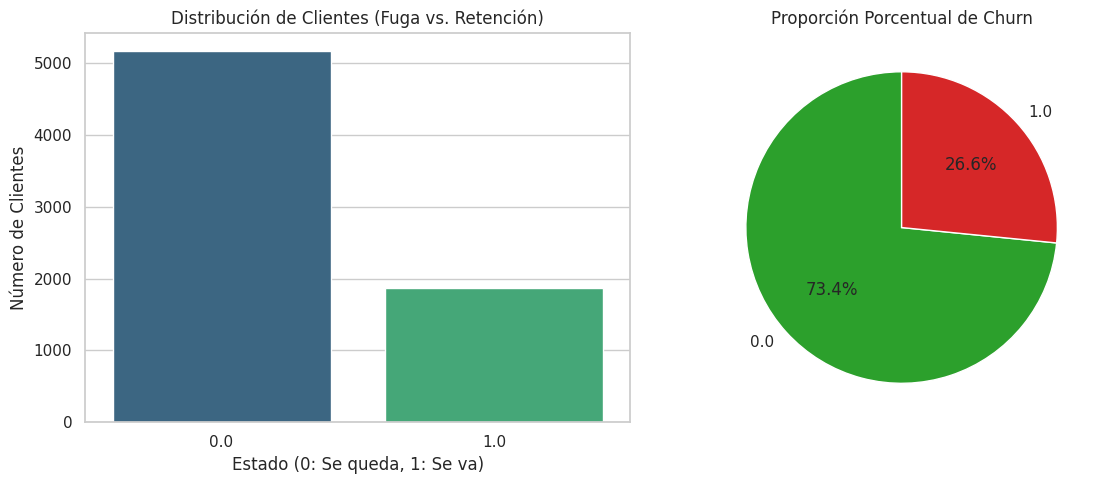

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Gráfico 1: Barras (Frecuencia)
plt.subplot(1, 2, 1)
ax = sns.countplot(x='Fuga_Cliente', data=df_final, palette='viridis')
plt.title('Distribución de Clientes (Fuga vs. Retención)')
plt.xlabel('Estado (0: Se queda, 1: Se va)')
plt.ylabel('Número de Clientes')

# Gráfico 2: Pastel (Proporción)
plt.subplot(1, 2, 2)
df_final['Fuga_Cliente'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#2ca02c', '#d62728'], startangle=90)
plt.title('Proporción Porcentual de Churn')
plt.ylabel('')

plt.tight_layout()
plt.show()

#📄Informe final